In [14]:
import pandas as pd
import numpy as np

In [15]:
df = pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [16]:
X = df.drop(columns=["PE"])
y = df["PE"]

In [17]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [18]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [19]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [20]:
df.shape

(9568, 5)

In [21]:
# scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [23]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [24]:
import torch
import torch.nn as nn

In [29]:
X_train_tensor = torch.tensor( X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor( y_train.values , dtype=torch.float32).view(-1,1)  # we have not scaled this so we are using .values()

X_test_tensor = torch.tensor( X_test_scaled , dtype=torch.float32)
y_test_tensor = torch.tensor( y_test.values , dtype=torch.float32).view(-1,1)

In [30]:
type(X_train_scaled)

numpy.ndarray

In [31]:
type(y_train)

pandas.core.series.Series

In [32]:
y_train.shape

(7654,)

In [33]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)           # input output
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [34]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


# Deep Learning

In [44]:
# Define an ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),        # input, output
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            #output layer
            nn.Linear(6,1),
    )

    def forward(self, x):
        return self.model(x)

In [45]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [46]:
# Train the ANN

train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs=100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0  # total training loss for 1 epoch

    for xb,yb in train_loader:        # xb= features of 1 batch, # yb= labels of 1 batch

        optimizer.zero_grad()
        
        outputs = model(xb)      # forward prop... predicted output of this batch
        loss = crietrion(outputs, yb)   #compute loss
        loss.backward()   # back prop... compute gradients
        optimizer.step()  # param update

        running_loss += loss.item()   # loss is a tensor => python float

    epoch_train_loss = running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)


    # validation        # bo backward propagation 
    model.eval()
    running_val_loss=0.0

    with torch.no_grad():       # no gradient compute
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ===> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")



    if epoch_val_loss<best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")   #.pt or .pth

epoch 1/100 ===> train loss = 205213.61497395832 & val loss = 202004.40625
epoch 2/100 ===> train loss = 192541.31725260417 & val loss = 178172.5625
epoch 3/100 ===> train loss = 152236.38108723957 & val loss = 122911.0703125
epoch 4/100 ===> train loss = 90241.86254882812 & val loss = 61931.25
epoch 5/100 ===> train loss = 41822.64944661458 & val loss = 28413.626953125
epoch 6/100 ===> train loss = 21814.82303059896 & val loss = 17686.53125
epoch 7/100 ===> train loss = 15403.418273925781 & val loss = 13473.2021484375
epoch 8/100 ===> train loss = 12056.662745157877 & val loss = 10466.076171875
epoch 9/100 ===> train loss = 9200.626682535807 & val loss = 7731.1533203125
epoch 10/100 ===> train loss = 6612.225595092774 & val loss = 5318.13134765625
epoch 11/100 ===> train loss = 4399.185370890299 & val loss = 3411.581298828125
epoch 12/100 ===> train loss = 2719.800584411621 & val loss = 2086.868896484375
epoch 13/100 ===> train loss = 1647.742377726237 & val loss = 1286.069091796875
e

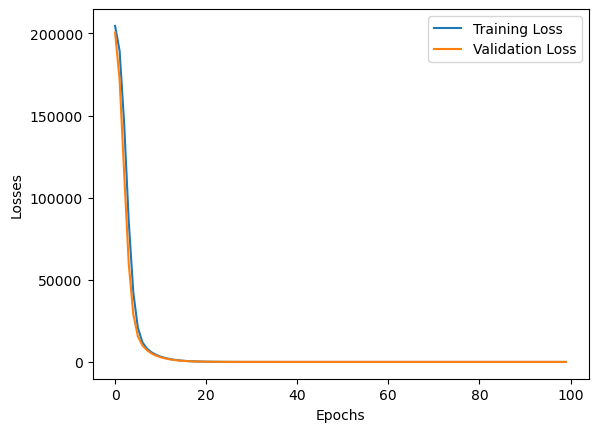

In [43]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [47]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [48]:
# Evaluate our model

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 21.1231632232666
Testing MSE: 19.48773765563965


In [49]:
from sklearn.metrics import r2_score

print("r2 score=", r2_score(y_test, test_preds))

r2 score= 0.9318953873936445


In [50]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.608215,433.27
1,437.054077,438.16
2,460.908081,458.42
3,475.772400,480.82
4,435.293518,441.41
...,...,...
1909,451.420898,456.70
1910,431.849121,438.04
1911,467.755249,467.80
1912,431.257111,437.14
